EXPERIMENT 05 - TASK 03
AdaBoost and Gradient Boosting
Name    : R. Karthik
Roll No : 25EU02904

AdaBoost Classifier
-------------------
Accuracy: 85.71%

Classification Report:
              precision    recall  f1-score   support

        Rock       0.86      0.83      0.84        29
        Mine       0.86      0.88      0.87        34

    accuracy                           0.86        63
   macro avg       0.86      0.85      0.86        63
weighted avg       0.86      0.86      0.86        63


Gradient Boosting Classifier
----------------------------
Accuracy: 80.95%

Best Gradient Boosting Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Tuned Gradient Boosting Accuracy: 74.60%

Model Performance Comparison:
                  Model  Accuracy (%)
               AdaBoost     85.714286
      Gradient Boosting     80.952381
Tuned Gradient Boosting     74.603175


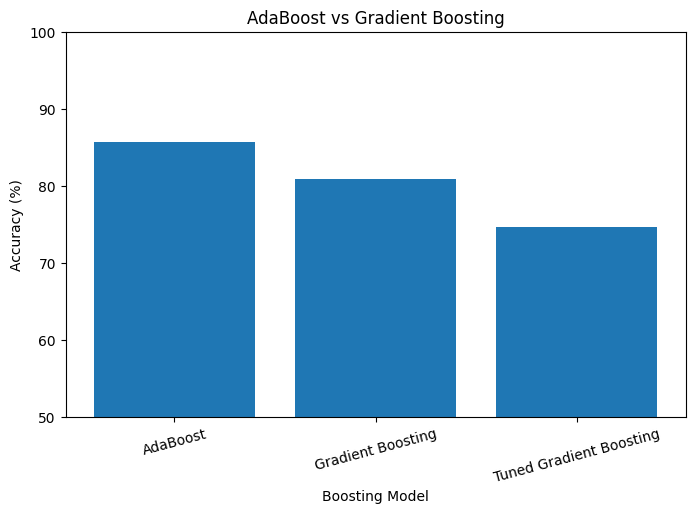


Top 10 Feature Importances:
Feature  Importance
   F_11    0.159374
    F_9    0.156701
   F_28    0.062546
    F_4    0.062405
   F_37    0.049908
   F_47    0.049428
   F_45    0.049045
   F_17    0.041964
   F_21    0.032201
   F_43    0.025449


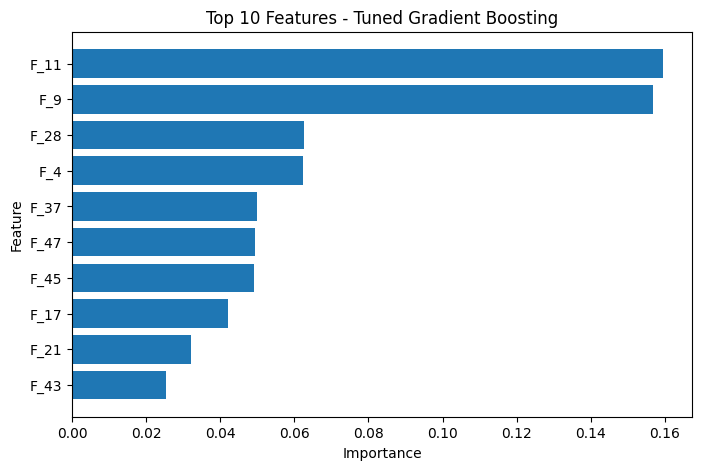


TASK 03 COMPLETED SUCCESSFULLY
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 05 - TASK 03
# AdaBoost and Gradient Boosting
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from sklearn.tree import DecisionTreeClassifier

print("=" * 60)
print("EXPERIMENT 05 - TASK 03")
print("AdaBoost and Gradient Boosting")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)


# ============================================================
# 1. LOAD SONAR DATASET
# ============================================================

sonar_url = (
    "https://raw.githubusercontent.com/jbrownlee/"
    "Datasets/master/sonar.csv"
)

features = [
    f"F_{i}"
    for i in range(1, 61)
]

columns = features + ["Class"]

sonar_df = pd.read_csv(
    sonar_url,
    header=None,
    names=columns
)

# Encode target
sonar_df["Target"] = sonar_df["Class"].map({
    "M": 1,
    "R": 0
})

X = sonar_df[features]

y = sonar_df["Target"]


# ============================================================
# 2. SCALE DATA
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)


# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)


# ============================================================
# 4. ADABOOST
# ============================================================

adaboost_model = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

adaboost_model.fit(
    X_train,
    y_train
)

ada_predictions = adaboost_model.predict(
    X_test
)

ada_accuracy = accuracy_score(
    y_test,
    ada_predictions
)

print("\nAdaBoost Classifier")
print("-------------------")

print(
    f"Accuracy: {ada_accuracy * 100:.2f}%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        ada_predictions,
        target_names=[
            "Rock",
            "Mine"
        ]
    )
)


# ============================================================
# 5. GRADIENT BOOSTING
# ============================================================

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_predictions = gb_model.predict(
    X_test
)

gb_accuracy = accuracy_score(
    y_test,
    gb_predictions
)

print("\nGradient Boosting Classifier")
print("----------------------------")

print(
    f"Accuracy: {gb_accuracy * 100:.2f}%"
)


# ============================================================
# 6. HYPERPARAMETER TUNING
# ============================================================

param_grid = {
    "learning_rate": [
        0.01,
        0.05,
        0.1
    ],
    "n_estimators": [
        50,
        100,
        150
    ],
    "max_depth": [
        3,
        4,
        5
    ]
}

grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_gb.fit(
    X_train,
    y_train
)

best_gb = grid_gb.best_estimator_

tuned_predictions = best_gb.predict(
    X_test
)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_predictions
)

print("\nBest Gradient Boosting Parameters:")

print(
    grid_gb.best_params_
)

print(
    f"Tuned Gradient Boosting Accuracy: "
    f"{tuned_accuracy * 100:.2f}%"
)


# ============================================================
# 7. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "AdaBoost",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "Accuracy (%)": [
        ada_accuracy * 100,
        gb_accuracy * 100,
        tuned_accuracy * 100
    ]
})

comparison = comparison.sort_values(
    by="Accuracy (%)",
    ascending=False
)

print("\nModel Performance Comparison:")
print(
    comparison.to_string(index=False)
)


# ============================================================
# 8. ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.xlabel("Boosting Model")

plt.ylabel("Accuracy (%)")

plt.title(
    "AdaBoost vs Gradient Boosting"
)

plt.ylim(50, 100)

plt.xticks(rotation=15)

plt.show()


# ============================================================
# 9. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_gb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top_features = importance.head(10)

print("\nTop 10 Feature Importances:")
print(
    top_features.to_string(index=False)
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Top 10 Features - Tuned Gradient Boosting"
)

plt.show()


# ============================================================
# CONCLUSION
# ============================================================

print("\n" + "=" * 60)
print("TASK 03 COMPLETED SUCCESSFULLY")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)